In [97]:
#Relatório de performance comercial.
#importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import seaborn as sns

In [98]:
#Relatório de performance comercial.

# Carga dos dados
order_items = pd.read_csv('olist_order_items_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')

In [99]:
#Relatório de performance comercial.

# Cruzamento central: Itens + Vendedores + Info do Pedido
df_vendas = pd.merge(order_items, sellers, on='seller_id')
def_completo = pd.merge(df_vendas, orders, on='order_id')
# Conversão de datas
cols_data = ['shipping_limit_date', 'order_delivered_carrier_date', 'order_approved_at']
for col in cols_data:
    df_completo[col] = pd.to_datetime(df_completo[col])

def_completo.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00


In [100]:
#Comparação entre Vendedores (Alto vs. Baixo Desempenho)

# 1. Criando o resumo consolidado por vendedor
# Agrupamos por 'seller_id' para calcular faturamento e volume de vendas
performance = df_completo.groupby('seller_id').agg({
    'price': 'sum',           # Faturamento Total
    'order_id': 'nunique',    # Volume de Pedidos Únicos
    'seller_state': 'first'   # Mantém o estado do vendedor
}).rename(columns={'price': 'faturamento_total', 'order_id': 'volume_pedidos'})

# 2. Identificando os Top 10 (Melhores faturamentos)
top_10_vendedores = performance.sort_values('faturamento_total', ascending=False).head(10)

# 3. Identificando os Bottom 10 (Menores faturamentos)
bottom_10_vendedores = performance.sort_values('faturamento_total', ascending=True).head(10)

# 4. Exibição dos resultados
print("=== Relatório de Performance de Vendedores ===")

print("\nTop 10 Melhores Vendedores (Maior Faturamento):")
display(top_10_vendedores)


print("\n10 Vendedores com Menor Faturamento:")
display(bottom_10_vendedores)



=== Relatório de Performance de Vendedores ===

Top 10 Melhores Vendedores (Maior Faturamento):


,faturamento_total,volume_pedidos,seller_state
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,SP
53243585a1d6dc2643021fd1853d8905,222776.05,358,BA
4a3ca9315b744ce9f8e9374361493884,200472.92,1806,SP
fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,SP
7c67e1448b00f6e969d365cea6b010ab,187923.89,982,SP
7e93a43ef30c4f03f38b393420bc753a,176431.87,336,SP
da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,SP
7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,SP
1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,SP



10 Vendedores com Menor Faturamento:


,faturamento_total,volume_pedidos,seller_state
seller_id,,,
cf6f6bc4df3999b9c6440f124fb2f687,3.50,1,SP
77128dec4bec4878c37ab7d6169d6f26,6.50,1,SP
1fa2d3def6adfa70e58c276bb64fe5bb,6.90,1,SP
702835e4b785b67a084280efca355756,7.60,1,MG
34aefe746cd81b7f3b23253ea28bef39,8.00,1,PR
ad14615bdd492b01b0d97922e87cb87f,8.25,1,SC
4965a7002cca77301c82d3f91b82e1a9,8.49,1,SP
0f94588695d71662beec8d883ffacf09,9.00,1,SC
c18309219e789960add0b2255ca4b091,9.90,1,RJ


In [101]:
# --- PASSO 1: Preparar as datas (Transformar texto em data de verdade) ---
df_completo['order_approved_at'] = pd.to_datetime(df_completo['order_approved_at'])
df_completo['order_delivered_carrier_date'] = pd.to_datetime(df_completo['order_delivered_carrier_date'])

# --- PASSO 2: Criar as colunas novas para o cálculo ---

# Calculando o tempo de postagem (Transformando a diferença em dias)
df_completo['tempo_postagem_dias'] = (df_completo['order_delivered_carrier_date'] - df_completo['order_approved_at']).dt.total_seconds() / 86400

# Criando uma coluna que diz True se foi cancelado e False se não foi
df_completo['foi_cancelado'] = (df_completo['order_status'] == 'canceled')

# --- PASSO 3: Agrupar tudo por vendedor ---

performance = df_completo.groupby('seller_id').agg({
    'price': 'sum',                 # Soma o faturamento
    'order_id': 'count',            # Conta quantos pedidos fez
    'tempo_postagem_dias': 'mean',  # Tira a média de dias de envio
    'foi_cancelado': 'mean'         # Tira a média de cancelamentos
})

# --- PASSO 4: Mudando os nomes das colunas para ficar fácil de ler
performance = performance.rename(columns={
    'price': 'faturamento_total',
    'order_id': 'total_pedidos',
    'tempo_postagem_dias': 'media_dias_envio',
    'foi_cancelado': 'taxa_cancelamento'
})

# Transformando a taxa de cancelamento em porcentagem 
performance['taxa_cancelamento'] = performance['taxa_cancelamento'] * 100

# PASSO 5: Ver o resultado final
performance.head(10)

,faturamento_total,total_pedidos,media_dias_envio,taxa_cancelamento
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,2.804352,0.0
001cca7ae9ae17fb1caed9dfb1094831,25080.03,239,2.179816,0.0
001e6ad469a905060d959994f1b41e4f,250.00,1,NaN,100.0
002100f778ceb8431b7a1020ff7ab48f,1234.50,55,3.542166,0.0
003554e2dce176b5555353e4f3555ac8,120.00,1,0.523623,0.0
004c9cd9d87a3c30c522c48c4fc07416,19712.71,170,1.399533,0.0
00720abe85ba0859807595bbf045a33b,1007.50,26,2.615760,0.0
00ab3eff1b5192e5f1a63bcecfee11c8,98.00,1,3.898762,0.0
00d8b143d12632bad99c0ad66ad52825,86.00,1,1.617083,0.0


C:\Users\tomaz\AppData\Local\Temp\ipykernel_5704\1553788991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


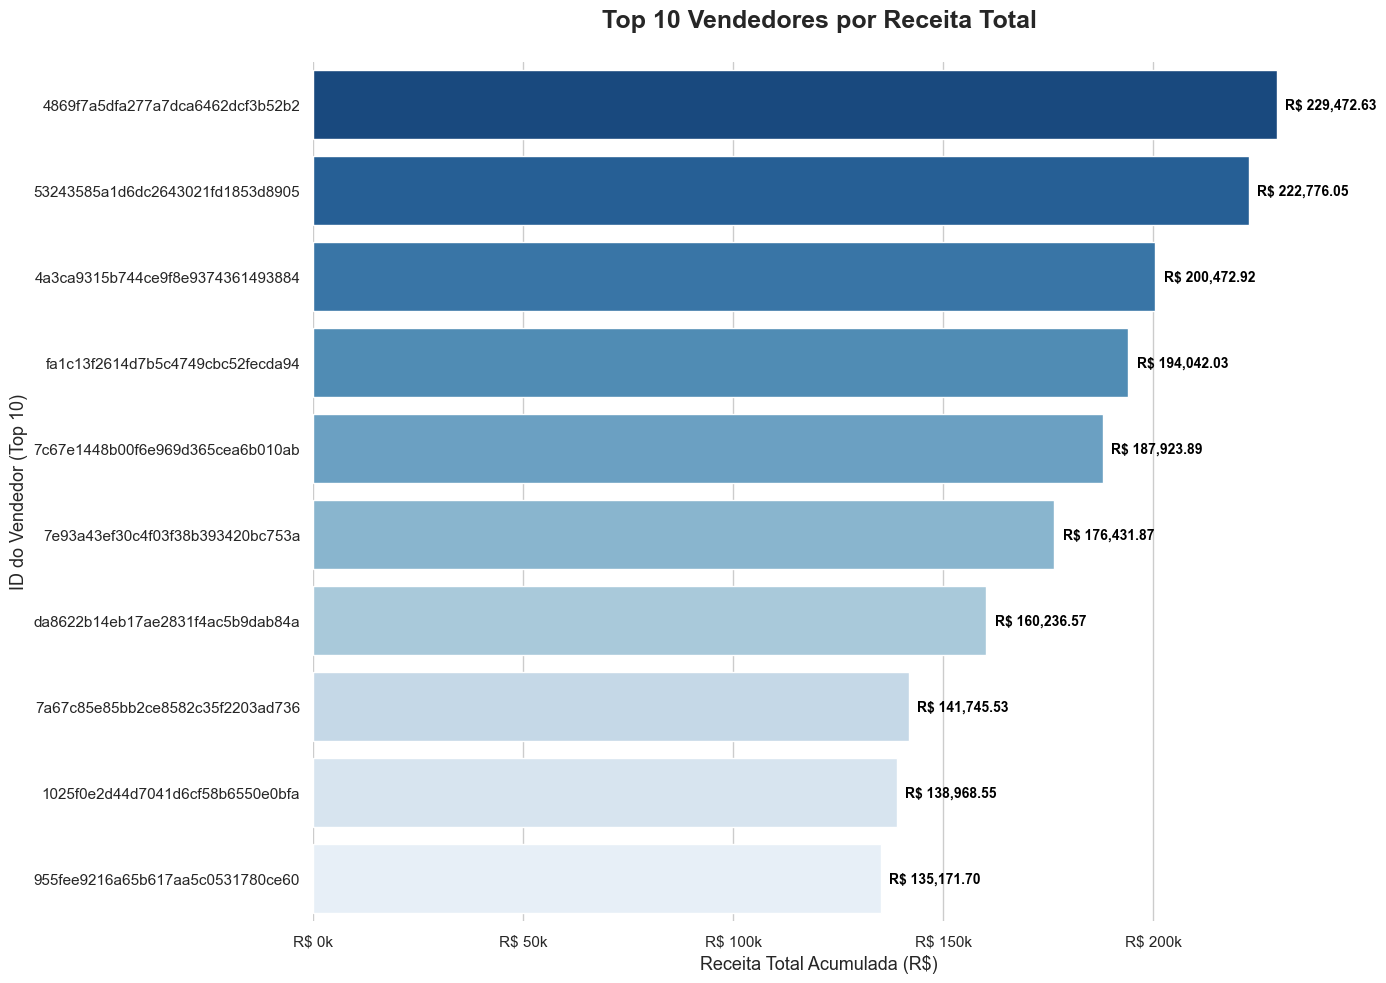

In [102]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    x=top_receita.values, 
    y=top_receita.index, 
    palette="Blues_r"
)
for i, v in enumerate(top_receita.values):
    ax.text(
        v + 2000,           # Posição X
        i,                  # Posição Y
        f'R$ {v:,.2f}',    # Texto formatado
        color='black', 
        va='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('Top 10 Vendedores por Receita Total', fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Receita Total Acumulada (R$)', fontsize=13)
plt.ylabel('ID do Vendedor (Top 10)', fontsize=13)
formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x/1000:.0f}k')
ax.xaxis.set_major_formatter(formatter)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

--- TEMA 4: SUGESTÕES OPERACIONAIS ---
Estados que precisam de novos centros logísticos (Envio mais lento):
seller_state
MA    4.550103
RN    3.901273
MS    3.729774
AM    3.427901
CE    3.095103
Name: tempo_postagem_dias, dtype: float64

Vendedores que precisam de treinamento urgente (Cancelamento > 15%):
                                  total_pedidos  taxa_cancelamento
seller_id                                                         
ec4608a1f76453166bb312b2968aeaf4             35          17.142857
ffff564a4f9085cd26170f4732393726             20          20.000000
2e3be8a987a30d7544dbbda6861cc14e             19          15.789474
4e8dacf3d38f281ae26c3e0321d92d88             15          33.333333
81783131d2a97c8d44d406a4be81b5d9             15          40.000000


C:\Users\tomaz\AppData\Local\Temp\ipykernel_5704\4012711288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sellers, x='seller_state', order=sellers['seller_state'].value_counts().index, palette='magma')


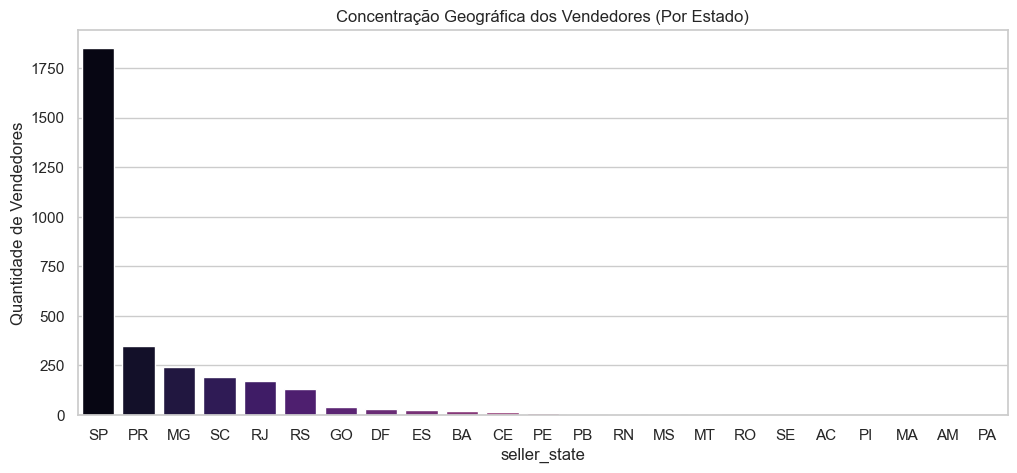

C:\Users\tomaz\AppData\Local\Temp\ipykernel_5704\4012711288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_atraso.values, y=top_atraso.index, palette="Reds_r")


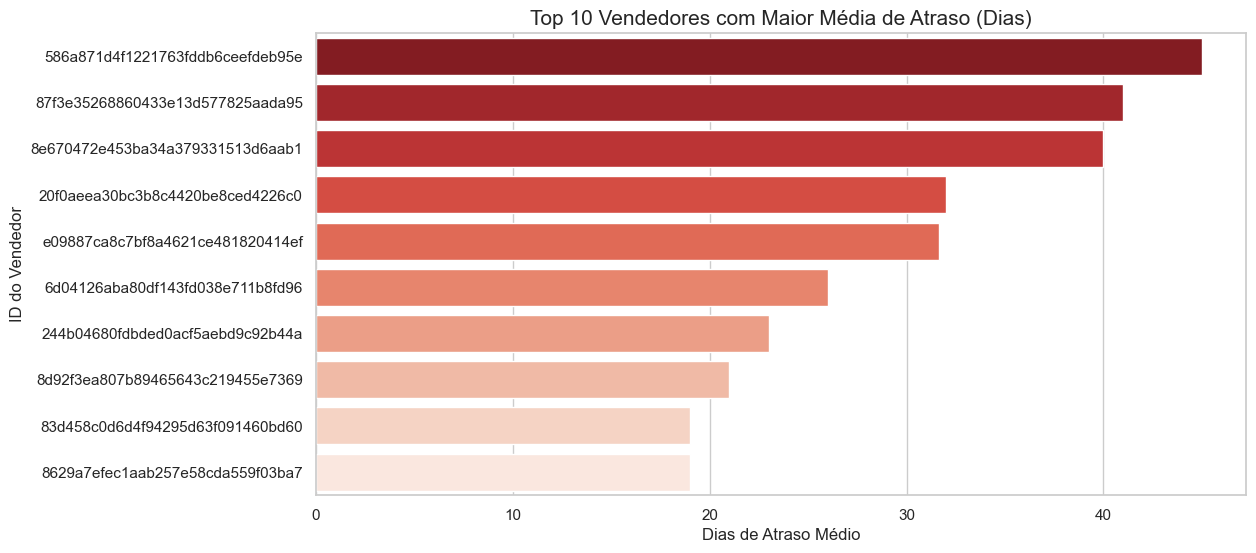

In [104]:
# NOVO: ANÁLISE POR ESTADO PARA MELHORIA OPERACIONAL - Cruzamos a performance com o estado original para ter essa visão
sugestao_melhoria = df_completo.groupby('seller_state')['tempo_postagem_dias'].mean().sort_values(ascending=False)

print("--- TEMA 4: SUGESTÕES OPERACIONAIS ---")
print("Estados que precisam de novos centros logísticos (Envio mais lento):")
print(sugestao_melhoria.head(5))

# Sugestão de Treinamento (Vendedores com muitos cancelamentos)
vendedores_treinamento = performance[performance['taxa_cancelamento'] > 15].sort_values('total_pedidos', ascending=False)
print("\nVendedores que precisam de treinamento urgente (Cancelamento > 15%):")
print(vendedores_treinamento[['total_pedidos', 'taxa_cancelamento']].head(5))

plt.figure(figsize=(12, 5))
sns.countplot(data=sellers, x='seller_state', order=sellers['seller_state'].value_counts().index, palette='magma')
plt.title('Concentração Geográfica dos Vendedores (Por Estado)')
plt.ylabel('Quantidade de Vendedores')
plt.show()

# Gráfico de Atraso Médio (Performance)
plt.figure(figsize=(12, 6))
top_atraso = performance_envio.sort_values(ascending=False).head(10)

sns.barplot(x=top_atraso.values, y=top_atraso.index, palette="Reds_r")

plt.title('Top 10 Vendedores com Maior Média de Atraso (Dias)', fontsize=15)
plt.xlabel('Dias de Atraso Médio')
plt.ylabel('ID do Vendedor')
plt.show()